Q1的任务要求如下：
比较三种运输方案：

a. 仅使用太空电梯系统

b. 仅使用传统火箭

c. 两者结合

安装必要的依赖包

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 配置matplotlib中文显示和负号显示，这里我就直接用英文了一劳永逸
plt.rcParams['font.family'] = 'DejaVu Sans'
# plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
# plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

下面开始考虑第一小问a，仅使用太空电梯系统

### 赖特定律（Wright's Law）成本模型

赖特定律也称为学习曲线理论，表明随着累积生产量的增加，单位成本会按幂律下降。

**公式**: C(x) = C₁ · x^(-b)

**参数说明**:
- C(x): 累积载荷量为x时的单位成本 ($/kg)
- C₁: 初始基准成本 ($/kg)
- x: 累积发射总载荷量 (kg)
- b: 学习率参数 (通常在0.1-0.3之间)

In [47]:
"""
赖特定律成本模型实现(基于年份)

关键改进：
- 学习曲线效应基于累积年份，而不是累积载荷量
- 技术改进来自发射经验积累，不是简单的载荷线性关系
"""

def wright_law_cost_annual_R(cumulative_years, C1, b):
    """
    基于赖特定律计算单位成本
    
    参数:
        cumulative_years: 累积发射年份
        C1: 初始基准成本 ($/kg) - 第一次发射的单位成本
        b: 学习率参数
    
    返回:
        单位成本 ($/kg)
    """
    if cumulative_years <= 0:
        return C1
    return C1 * (((3*cumulative_years+10)/10) ** (-b))

def wright_law_cost_annual_H(cumulative_years, C1, b):
    """
    基于赖特定律计算单位成本
    
    参数:
        cumulative_years: 累积发射年份
        C1: 初始基准成本 ($/kg) - 第一次发射的单位成本
        b: 学习率参数
    
    返回:
        单位成本 ($/kg)
    """
    if cumulative_years <= 0:
        return C1
    return C1 * (((cumulative_years+10)/10) ** (-b))


def calculate_total_cost_with_learning_R(total_payload_kg, payload_per_year_kg, C1, b):
    """
    计算考虑学习曲线效应的总成本
    
    参数:
        total_payload_kg: 总载荷量 (kg)
        payload_per_year_kg: 每年发射的载荷量 (kg)，例如150吨 = 150,000 kg
        C1: 初始基准成本 ($/kg)
        b: 学习率参数
    
    返回:
        total_cost: 总成本 ($)
        avg_cost: 平均单位成本 ($/kg)
        cost_history: 成本历史记录 [(发射次数, 累积载荷kg, 单位成本$/kg, 该年发射总成本$)]
        total_years: 总发射年数
    """
    # 计算所需的总发射年数
    total_years = int(np.ceil(total_payload_kg / payload_per_year_kg))
    
    total_cost = 0
    cumulative_payload = 0
    cost_history = []
    
    # 逐年发射计算
    for year_num in range(1, total_years + 1):
        # 计算这年发射的载荷（最后一次可能不足）
        if year_num < total_years:
            current_payload = payload_per_year_kg
        else:
            current_payload = total_payload_kg - cumulative_payload
        
        # 基于累积发射年数计算当前的单位成本
        unit_cost = wright_law_cost_annual_R(year_num, C1, b)
        
        # 计算本年度发射的总成本
        year_cost = unit_cost * current_payload
        total_cost += year_cost
        
        # 更新累积载荷
        cumulative_payload += current_payload
        
        # 记录历史（每隔一定次数记录，避免数据过多）
        cost_history.append((year_num, cumulative_payload, unit_cost, year_cost))
    
    avg_cost = total_cost / total_payload_kg
    return total_cost, avg_cost, cost_history, total_years

def calculate_total_cost_with_learning_H(total_payload_kg, payload_per_year_kg, C1, b):
    """
    计算考虑学习曲线效应的总成本
    
    参数:
        total_payload_kg: 总载荷量 (kg)
        payload_per_year_kg: 每年发射的载荷量 (kg)，例如150吨 = 150,000 kg
        C1: 初始基准成本 ($/kg)
        b: 学习率参数
    
    返回:
        total_cost: 总成本 ($)
        avg_cost: 平均单位成本 ($/kg)
        cost_history: 成本历史记录 [(发射次数, 累积载荷kg, 单位成本$/kg, 该年发射总成本$)]
        total_years: 总发射年数
    """
    # 计算所需的总发射年数
    total_years = int(np.ceil(total_payload_kg / payload_per_year_kg))
    
    total_cost = 0
    cumulative_payload = 0
    cost_history = []
    
    # 逐年发射计算
    for year_num in range(1, total_years + 1):
        # 计算这年发射的载荷（最后一次可能不足）
        if year_num < total_years:
            current_payload = payload_per_year_kg
        else:
            current_payload = total_payload_kg - cumulative_payload
        
        # 基于累积发射年数计算当前的单位成本
        unit_cost = wright_law_cost_annual_R(year_num, C1, b)
        
        # 计算本年度发射的总成本
        year_cost = unit_cost * current_payload
        total_cost += year_cost
        
        # 更新累积载荷
        cumulative_payload += current_payload
        
        # 记录历史（每隔一定次数记录，避免数据过多）
        cost_history.append((year_num, cumulative_payload, unit_cost, year_cost))
    
    avg_cost = total_cost / total_payload_kg
    return total_cost, avg_cost, cost_history, total_years

# 测试赖特定律模型
print("=== 赖特定律成本模型测试（基于年份）===\n")

# 参数设置
C1_rocket = 300  # 火箭初始成本 500$/kg

# 火箭基础参数
total_materials = 100_000_000  # 总物资需求：1亿吨
capacity_per_rocket = 150  # 每个火箭运输能力：100-150,这里取最大
num_launch_site = 10  # 火箭基地数量
num_launch_fre_per_day = 1 # 每个基地每天发送频率
rocket_cost_per_kg = 300 # 火箭运输成本300-500美刀/kg，这里取500

# 火箭运输参数
payload_per_year = 365 * num_launch_site * num_launch_fre_per_day * capacity_per_rocket  # 每年发射吨数
payload_per_year_kg = payload_per_year * 1000  # 转换为kg
b_values = [0.15, 0.20, 0.30]  # 不同的学习率参数

# 测试案例：发射不同年数后的成本
test_years = [1, 10, 50, 150, 200]

print(f"每年发射载荷: {payload_per_year} 吨\n")

for b in b_values:
    print(f"学习率参数 b = {b} (每发射年份数翻倍，成本降至 {100*(2**(-b)):.1f}%)")
    print("-" * 80)
    print(f"{'发射年数':<12} {'累积载荷(吨)':<18} {'单位成本($/kg)':<20} {'成本下降':<15}")
    print("-" * 80)
    for years in test_years:
        cumulative_tons = years * payload_per_year
        unit_cost = wright_law_cost_annual_R(years, C1_rocket, b)
        reduction = (1 - unit_cost/C1_rocket) * 100
        print(f"{years:<12} {cumulative_tons:<18,} ${unit_cost:<19.2f} {reduction:.1f}%")
    print()


=== 赖特定律成本模型测试（基于年份）===

每年发射载荷: 547500 吨

学习率参数 b = 0.15 (每发射年份数翻倍，成本降至 90.1%)
--------------------------------------------------------------------------------
发射年数         累积载荷(吨)            单位成本($/kg)           成本下降           
--------------------------------------------------------------------------------
1            547,500            $288.42              3.9%
10           5,475,000          $243.68              18.8%
50           27,375,000         $197.93              34.0%
150          82,125,000         $168.93              43.7%
200          109,500,000        $161.93              46.0%

学习率参数 b = 0.2 (每发射年份数翻倍，成本降至 87.1%)
--------------------------------------------------------------------------------
发射年数         累积载荷(吨)            单位成本($/kg)           成本下降           
--------------------------------------------------------------------------------
1            547,500            $284.66              5.1%
10           5,475,000          $227.36              24.2%
50        

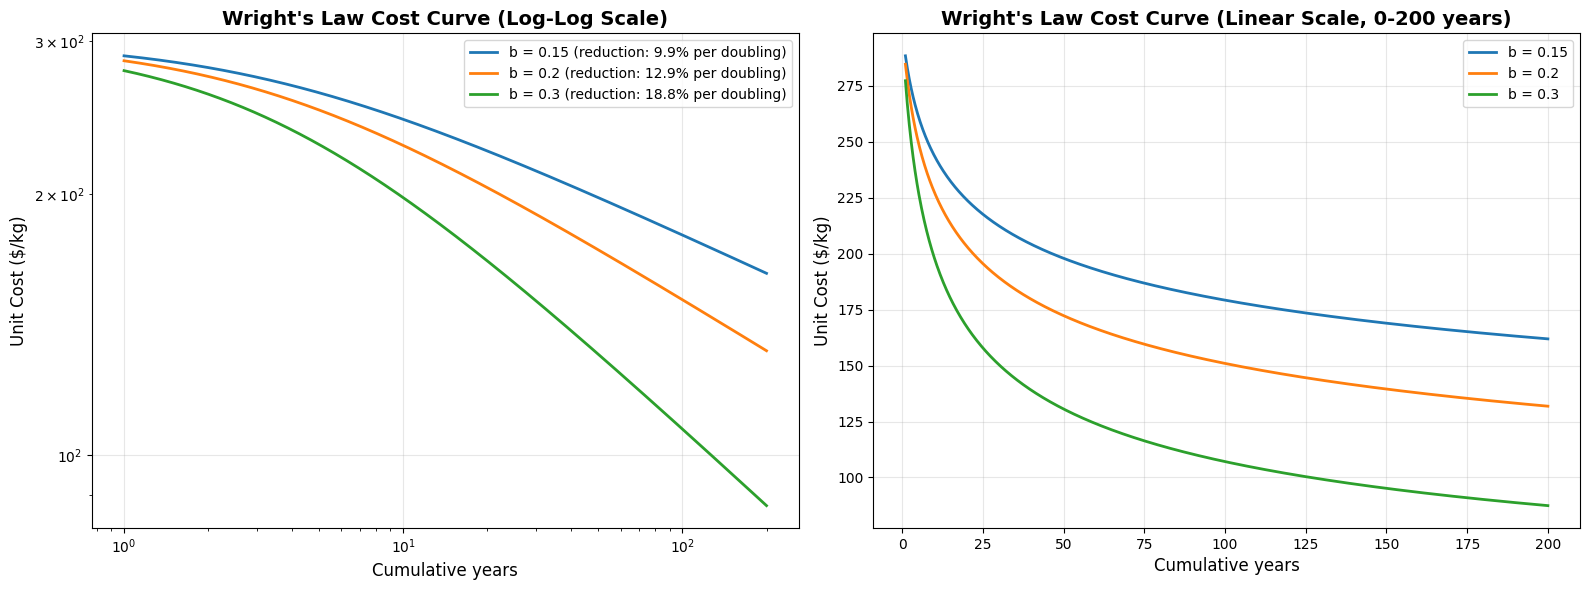

图表说明：
- 左图使用对数坐标，展示整个范围内的成本下降趋势
- 右图使用线性坐标，聚焦在0-200年范围内的成本变化
- 学习率参数b越大，成本下降越快


In [48]:
"""
可视化赖特定律成本曲线
"""

# 生成累积载荷数据 200年
cumulative_years = np.logspace(0, np.log10(200), 1000)  # 200年
# 参数设置
C1_rocket = 300  # 初始成本 300美刀/kg
b_values = [0.15, 0.20, 0.30]

# 创建图表
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 左图：对数坐标
for b in b_values:
    costs = [wright_law_cost_annual_R(x, C1_rocket, b) for x in cumulative_years]
    ax1.loglog(cumulative_years, costs, linewidth=2, 
               label=f'b = {b} (reduction: {100*(1-2**(-b)):.1f}% per doubling)')

ax1.set_xlabel('Cumulative years', fontsize=12)
ax1.set_ylabel('Unit Cost ($/kg)', fontsize=12)
ax1.set_title('Wright\'s Law Cost Curve (Log-Log Scale)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# 右图：线性坐标
cumulative_years_linear = np.linspace(1, 200, 1000)
for b in b_values:
    costs = [wright_law_cost_annual_R(x, C1_rocket, b) for x in cumulative_years_linear]
    ax2.plot(cumulative_years_linear, costs, linewidth=2, 
             label=f'b = {b}')

ax2.set_xlabel('Cumulative years', fontsize=12)
ax2.set_ylabel('Unit Cost ($/kg)', fontsize=12)
ax2.set_title('Wright\'s Law Cost Curve (Linear Scale, 0-200 years)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("图表说明：")
print("- 左图使用对数坐标，展示整个范围内的成本下降趋势")
print("- 右图使用线性坐标，聚焦在0-200年范围内的成本变化")
print("- 学习率参数b越大，成本下降越快")

In [49]:
"""
计算仅使用太空电梯系统运输1亿吨物资所需的时间及金钱
(静态计算)
"""
# 基础参数
total_materials = 100_000_000  # 总物资需求：1亿吨
annual_capacity_per_harbor = 179_000  # 每个银河港口年运输能力：17.9万吨
num_harbors = 3  # 银河港口数量
habor_cost_per_kg = 30 # 太空电梯运输成本10-50美刀/kg，这里取30
    
print("=== 太空电梯系统运输能力计算 ===")
print(f"总物资需求: {total_materials:,} 吨")
print(f"每个银河港口年运输能力: {annual_capacity_per_harbor:,} 吨")
print(f"银河港口数量: {num_harbors}个")
    
# 计算总年运输能力
total_annual_capacity = annual_capacity_per_harbor * num_harbors
print(f"太空电梯系统总年运输能力: {total_annual_capacity:,} 吨")

# 计算总运输耗资
total_anual_cost = total_materials * 1000 * habor_cost_per_kg
print(f"太空电梯系统总运输耗资: {total_anual_cost:,} 美元")
    
# 计算所需年数
years_needed = total_materials / total_annual_capacity
print(f"理论所需年数: {years_needed:.2f} 年")
    
# 分解为年月日
full_years = int(years_needed)
months = int((years_needed - full_years) * 12)
days = int(((years_needed - full_years) * 12 - months) * 30.44)  # 平均每月30.44天
    
print(f"运输时间分解: {full_years} 年 {months} 月 {days} 天")
print(f"约合 {years_needed*12:.1f} 个月")
print(f"约合 {years_needed*365:.0f} 天")


    

=== 太空电梯系统运输能力计算 ===
总物资需求: 100,000,000 吨
每个银河港口年运输能力: 179,000 吨
银河港口数量: 3个
太空电梯系统总年运输能力: 537,000 吨
太空电梯系统总运输耗资: 3,000,000,000,000 美元
理论所需年数: 186.22 年
运输时间分解: 186 年 2 月 19 天
约合 2234.6 个月
约合 67970 天


In [50]:
"""
使用赖特定律计算太空电梯运输的动态成本
"""

# 基础参数
total_materials = 100_000_000  # 总物资需求：1亿吨
total_materials_kg = total_materials * 1000  # 转换为kg


# 电梯基础参数
annual_capacity_per_harbor = 179_000  # 每个银河港口年运输能力：17.9万吨
num_harbors = 3  # 银河港口数量
habor_cost_per_kg = 30 # 太空电梯运输成本10-50美刀/kg，这里取20

# 电梯运输参数
payload_per_year = annual_capacity_per_harbor * num_harbors  # 每年运输吨数
payload_per_year_kg = payload_per_year * 1000  # 转换为kg

# 赖特定律参数
C1_harbor = 30  # 初始基准成本 ($/kg)
b_harbor = 0.15  # 学习率参数

print("=== 基于赖特定律的太空电梯运输成本计算 ===\n")
print(f"总物资需求: {total_materials:,} 吨 ({total_materials_kg:,} kg)")
print(f"每年运输载荷: {payload_per_year} 吨")
print(f"初始单位成本 C₁: ${C1_harbor}/kg")
print(f"学习率参数 b: {b_harbor}")
print(f"太空电梯系统总运输耗资: {total_anual_cost:,} (约 ${total_anual_cost/1e9:.2f} 亿美元)")

# 计算总成本（基于发射次数）
total_cost, avg_cost, cost_history, total_years = calculate_total_cost_with_learning_H(
    total_materials_kg, payload_per_year_kg, C1_harbor, b_harbor
)
    
# 计算所需年数
years_needed = total_materials / total_annual_capacity
print(f"理论所需年数: {years_needed:.2f} 年")


print("-" * 70)
print(f"总运输年数: {total_years:,} 年")
print(f"总运输成本: ${total_cost:,.2f} (约 ${total_cost/1e9:.2f} 亿美元)")
print(f"平均单位成本: ${avg_cost:.2f}/kg")
print(f"初始单位成本: ${C1_harbor}/kg")
print(f"成本节省: {100*(1 - avg_cost/C1_harbor):.2f}% (相比固定成本)")

# 显示关键年份的成本变化
print("\n关键年份成本变化：")
print("-" * 70)
print(f"{'年份':<12} {'累积载荷(吨)':<18} {'单位成本($/kg)':<20}")
print("-" * 70)
milestones = [1, 10, 100, 1000, 10000, 100000, total_years]
for milestone in milestones:
    if milestone <= total_years:
        unit_cost = wright_law_cost_annual_H(milestone, C1_harbor, b_harbor)
        cumulative_tons = min(milestone * payload_per_year, total_materials)
        print(f"{milestone:<12,} {cumulative_tons:<18,} ${unit_cost:<19.2f}")

print("-" * 70)

# 对比不同学习率下的成本
print("\n不同学习率参数下的总成本对比：")
print("-" * 70)
for b in [0.10, 0.15, 0.20, 0.25, 0.30]:
    cost, avg, _, launches = calculate_total_cost_with_learning_H(
        total_materials_kg, payload_per_year_kg, C1_harbor, b
    )
    print(f"b = {b:.2f}: 年数{launches:,}年 | 总成本 ${cost/1e9:.2f}亿美元 | 平均成本 ${avg:.2f}/kg | 节省 {100*(1-avg/C1_harbor):.1f}%")


=== 基于赖特定律的太空电梯运输成本计算 ===

总物资需求: 100,000,000 吨 (100,000,000,000 kg)
每年运输载荷: 537000 吨
初始单位成本 C₁: $30/kg
学习率参数 b: 0.15
太空电梯系统总运输耗资: 3,000,000,000,000 (约 $3000.00 亿美元)
理论所需年数: 186.22 年
----------------------------------------------------------------------
总运输年数: 187 年
总运输成本: $1,892,876,374,066.00 (约 $1892.88 亿美元)
平均单位成本: $18.93/kg
初始单位成本: $30/kg
成本节省: 36.90% (相比固定成本)

关键年份成本变化：
----------------------------------------------------------------------
年份           累积载荷(吨)            单位成本($/kg)          
----------------------------------------------------------------------
1            537,000            $29.57              
10           5,370,000          $27.04              
100          53,700,000         $20.94              
187          100,000,000        $19.18              
----------------------------------------------------------------------

不同学习率参数下的总成本对比：
----------------------------------------------------------------------
b = 0.10: 年数187年 | 总成本 $2202.85亿美元 | 平均成本 $22.03/kg | 节

下面开始考虑第二小问b，仅使用火箭运输

In [51]:
"""
计算仅使用火箭系统运输1亿吨物资所需的时间及金钱
(静态计算)
"""
# 基础参数
total_materials = 100_000_000  # 总物资需求：1亿吨
capacity_per_rocket = 150  # 每个火箭运输能力：100-150,这里取最大
num_launch_site = 10  # 火箭基地数量
num_launch_fre_per_day = 1 # 每个基地每天发送频率

rocket_cost_per_kg = 300 # 火箭运输成本300-500美刀/kg，这里取300
    
print("=== 火箭系统运输能力计算 ===")
print(f"总物资需求: {total_materials:,} 吨")
print(f"每个火箭运输能力: {capacity_per_rocket:,} 吨")
print(f"火箭基地数量: {num_launch_site}个")
print(f"每个基地每天发送频率: {num_launch_fre_per_day}次")
    
# 计算总年运输能力
total_annual_capacity = capacity_per_rocket * num_launch_site * num_launch_fre_per_day * 365
print(f"火箭系统总年运输能力: {total_annual_capacity:,} 吨")

# 计算总运输耗资
total_anual_cost = total_materials * 1000 * rocket_cost_per_kg
print(f"火箭系统总运输耗资: {total_anual_cost:,} 美元")
    
# 计算所需年数
years_needed = total_materials / total_annual_capacity
print(f"理论所需年数: {years_needed:.2f} 年")
    
# 分解为年月日
    
print(f"运输时间分解: {full_years} 年 {months} 月 {days} 天")
print(f"约合 {years_needed*12:.1f} 个月")
print(f"约合 {years_needed*365:.0f} 天")


print(f"约合 {years_needed*365:.0f} 天")

=== 火箭系统运输能力计算 ===
总物资需求: 100,000,000 吨
每个火箭运输能力: 150 吨
火箭基地数量: 10个
每个基地每天发送频率: 1次
火箭系统总年运输能力: 547,500 吨
火箭系统总运输耗资: 30,000,000,000,000 美元
理论所需年数: 182.65 年
运输时间分解: 186 年 2 月 19 天
约合 2191.8 个月
约合 66667 天
约合 66667 天


In [60]:
"""
使用赖特定律计算火箭运输的动态成本
"""

# 基础参数
total_materials = 100_000_000  # 总物资需求：1亿吨
total_materials_kg = total_materials * 1000  # 转换为kg


# 火箭基础参数
capacity_per_rocket = 150  # 每个火箭运输能力：100-150,这里取最大
num_launch_site = 10  # 火箭基地数量
num_launch_fre_per_day = 1 # 每个基地每天发送频率
rocket_cost_per_kg = 300 # 火箭运输成本300-500美刀/kg，这里取300

# 火箭运输参数
payload_per_year = 365 * num_launch_site * num_launch_fre_per_day * capacity_per_rocket  # 每年发射吨数
payload_per_year_kg = payload_per_year * 1000  # 转换为kg

# 赖特定律参数
C1_rocket = 300  # 初始基准成本 ($/kg)
b_rocket = 0.15  # 学习率参数

print("=== 基于赖特定律的火箭运输成本计算===\n")
print(f"总物资需求: {total_materials:,} 吨 ({total_materials_kg:,} kg)")
print(f"每年火箭发射载荷: {payload_per_year} 吨")
print(f"初始单位成本 C₁: ${C1_rocket}/kg")
print(f"学习率参数 b: {b_rocket}")
print(f"火箭系统总运输耗资: {total_anual_cost:,} (约 ${total_anual_cost/1e9:.2f} 亿美元)")

# 计算总成本（基于发射次数）
total_cost, avg_cost, cost_history, total_years = calculate_total_cost_with_learning_R(
    total_materials_kg, payload_per_year_kg, C1_rocket, b_rocket
)

# 计算所需年数
years_needed = total_materials / total_annual_capacity
print(f"理论所需年数: {years_needed:.2f} 年")

print("-" * 70)
print(f"总发射年数: {total_years:,} 年")
print(f"总运输成本: ${total_cost:,.2f} (约 ${total_cost/1e9:.2f} 亿美元)")
print(f"平均单位成本: ${avg_cost:.2f}/kg")
print(f"初始单位成本: ${C1_rocket}/kg")
print(f"成本节省: {100*(1 - avg_cost/C1_rocket):.2f}% (相比固定成本)")

# 显示关键发射节点的成本变化
print("\n关键年份成本变化：")
print("-" * 70)
print(f"{'发射次数':<12} {'累积载荷(吨)':<18} {'单位成本($/kg)':<20}")
print("-" * 70)
milestones = [1, 10, 100, 1000, 10000, 100000, total_years]
for milestone in milestones:
    if milestone <= total_years:
        unit_cost = wright_law_cost_annual_R(milestone, C1_rocket, b_rocket)
        cumulative_tons = min(milestone * payload_per_year, total_materials)
        print(f"{milestone:<12,} {cumulative_tons:<18,} ${unit_cost:<19.2f}")

print("-" * 70)

# 对比不同学习率下的成本
print("\n不同学习率参数下的总成本对比：")
print("-" * 70)
for b in [0.10, 0.15, 0.20, 0.25, 0.30]:
    cost, avg, _, launches = calculate_total_cost_with_learning_R(
        total_materials_kg, payload_per_year_kg, C1_rocket, b
    )
    print(f"b = {b:.2f}: 年数{launches:,}年 | 总成本 ${cost/1e9:.2f}亿美元 | 平均成本 ${avg:.2f}/kg | 节省 {100*(1-avg/C1_rocket):.1f}%")


=== 基于赖特定律的火箭运输成本计算===

总物资需求: 100,000,000 吨 (100,000,000,000 kg)
每年火箭发射载荷: 547500 吨
初始单位成本 C₁: $300/kg
学习率参数 b: 0.15
火箭系统总运输耗资: 30,000,000,000,000 (约 $30000.00 亿美元)
理论所需年数: 92.21 年
----------------------------------------------------------------------
总发射年数: 183 年
总运输成本: $18,978,580,064,730.57 (约 $18978.58 亿美元)
平均单位成本: $189.79/kg
初始单位成本: $300/kg
成本节省: 36.74% (相比固定成本)

关键年份成本变化：
----------------------------------------------------------------------
发射次数         累积载荷(吨)            单位成本($/kg)          
----------------------------------------------------------------------
1            547,500            $288.42             
10           5,475,000          $243.68             
100          54,750,000         $179.23             
183          100,000,000        $164.06             
----------------------------------------------------------------------

不同学习率参数下的总成本对比：
----------------------------------------------------------------------
b = 0.10: 年数183年 | 总成本 $22067.39亿美元 | 平均成本 $220.67/k

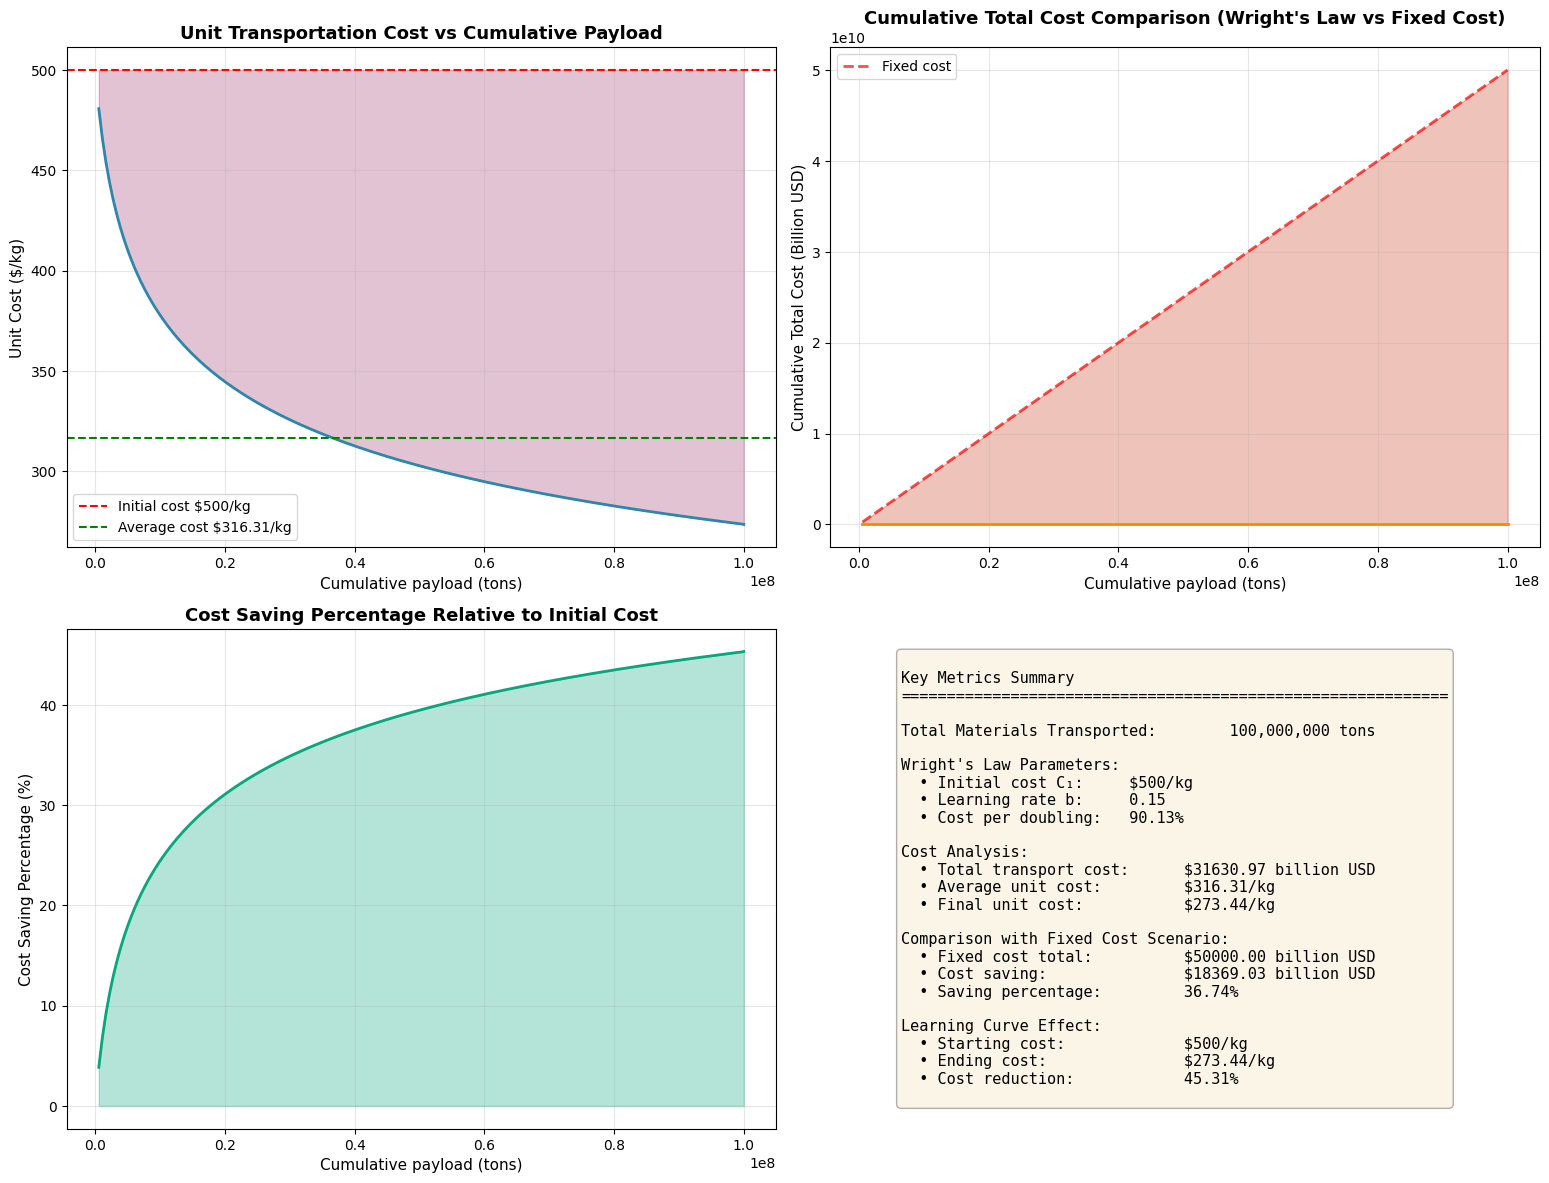


图表说明：
• 左上：展示单位成本如何随累积运输量递减
• 右上：对比赖特定律与固定成本方案的累积总成本差异
• 左下：显示相对初始成本的节省百分比
• 右下：汇总关键指标和对比数据


In [53]:
"""
可视化运输1亿吨物资过程中的成本演变
"""

# 提取成本历史数据 
# cost_history 格式: [(运输年数, 累积载荷kg, 单位成本$/kg, 本年发射总成本$)]
years_numbers = [x[0] for x in cost_history]  # 运输年数
cumulative_payload_tons = [x[1] / 1000 for x in cost_history]  # 转换为吨
unit_costs = [x[2] for x in cost_history]  # 单位成本

# 计算累积总成本
cumulative_costs = []
cumulative_cost = 0
for launch_num, cum_payload_kg, unit_cost, launch_cost in cost_history:
    cumulative_cost += launch_cost
    cumulative_costs.append(cumulative_cost / 1e9)  # 转换为亿美元

# 创建图表
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 子图1: 单位成本变化
ax1 = axes[0, 0]
ax1.plot(cumulative_payload_tons, unit_costs, linewidth=2, color='#2E86AB')
ax1.axhline(y=C1_rocket, color='red', linestyle='--', linewidth=1.5, 
            label=f'Initial cost ${C1_rocket}/kg')
ax1.axhline(y=avg_cost, color='green', linestyle='--', linewidth=1.5, 
            label=f'Average cost ${avg_cost:.2f}/kg')
ax1.fill_between(cumulative_payload_tons, unit_costs, C1_rocket, alpha=0.3, color='#A23B72')
ax1.set_xlabel('Cumulative payload (tons)', fontsize=11)
ax1.set_ylabel('Unit Cost ($/kg)', fontsize=11)
ax1.set_title('Unit Transportation Cost vs Cumulative Payload', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# 子图2: 累积总成本
ax2 = axes[0, 1]
ax2.plot(cumulative_payload_tons, cumulative_costs, linewidth=2, color='#F18F01')
# 计算固定成本下的累积成本
fixed_cumulative_costs = [x * C1_rocket for x in cumulative_payload_tons]
ax2.plot(cumulative_payload_tons, fixed_cumulative_costs, linewidth=2, 
         color='red', linestyle='--', alpha=0.7, label='Fixed cost')
ax2.fill_between(cumulative_payload_tons, cumulative_costs, fixed_cumulative_costs, 
                  alpha=0.3, color='#C73E1D')
ax2.set_xlabel('Cumulative payload (tons)', fontsize=11)
ax2.set_ylabel('Cumulative Total Cost (Billion USD)', fontsize=11)
ax2.set_title('Cumulative Total Cost Comparison (Wright\'s Law vs Fixed Cost)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

# 子图3: 成本节省百分比
ax3 = axes[1, 0]
savings_percent = [(C1_rocket - uc) / C1_rocket * 100 for uc in unit_costs]
ax3.plot(cumulative_payload_tons, savings_percent, linewidth=2, color='#06A77D')
ax3.fill_between(cumulative_payload_tons, 0, savings_percent, alpha=0.3, color='#06A77D')
ax3.set_xlabel('Cumulative payload (tons)', fontsize=11)
ax3.set_ylabel('Cost Saving Percentage (%)', fontsize=11)
ax3.set_title('Cost Saving Percentage Relative to Initial Cost', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 子图4: 关键指标对比
ax4 = axes[1, 1]
ax4.axis('off')

metrics_text = f"""
Key Metrics Summary
{'='*60}

Total Materials Transported:        {total_materials:,} tons

Wright's Law Parameters:
  • Initial cost C₁:     ${C1_rocket}/kg
  • Learning rate b:     {b_rocket}
  • Cost per doubling:   {100*(2**(-b_rocket)):.2f}%

Cost Analysis:
  • Total transport cost:      ${total_cost/1e9:.2f} billion USD
  • Average unit cost:         ${avg_cost:.2f}/kg
  • Final unit cost:           ${unit_costs[-1]:.2f}/kg

Comparison with Fixed Cost Scenario:
  • Fixed cost total:          ${(C1_rocket * total_materials_kg)/1e9:.2f} billion USD
  • Cost saving:               ${(C1_rocket * total_materials_kg - total_cost)/1e9:.2f} billion USD
  • Saving percentage:         {100*(1 - avg_cost/C1_rocket):.2f}%

Learning Curve Effect:
  • Starting cost:             ${C1_rocket}/kg
  • Ending cost:               ${unit_costs[-1]:.2f}/kg
  • Cost reduction:            {100*(C1_rocket - unit_costs[-1])/C1_rocket:.2f}%
"""

ax4.text(0.1, 0.95, metrics_text, transform=ax4.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n图表说明：")
print("• 左上：展示单位成本如何随累积运输量递减")
print("• 右上：对比赖特定律与固定成本方案的累积总成本差异")
print("• 左下：显示相对初始成本的节省百分比")
print("• 右下：汇总关键指标和对比数据")

下面开始考虑第三小问c，这两种方法的结合

首先考虑以最短时间完成建设任务，这里假设电梯和火箭都以最大限度运行

In [61]:
"""
计算以最短时间完成建设任务所需的时间
"""
# 基础参数
total_materials = 100_000_000  # 总物资需求：1亿吨
annual_capacity_per_harbor = 179_000  # 每个银河港口年运输能力：17.9万吨
num_harbors = 3  # 银河港口数量

capacity_per_rocket = 150  # 每个火箭运输能力：100-150
num_launch_site = 10  # 火箭基地数量
num_launch_fre_per_day = 3 # 每个基地每天发送频率


# 计算火箭总年运输能力
rocket_total_annual_capacity = capacity_per_rocket * num_launch_site * num_launch_fre_per_day * 365
print(f"火箭系统总年运输能力: {rocket_total_annual_capacity:,} 吨")

# 计算电梯总年运输能力
harbor_total_annual_capacity = annual_capacity_per_harbor * num_harbors
print(f"太空电梯系统总年运输能力: {harbor_total_annual_capacity:,} 吨")

total_annual_capacity = rocket_total_annual_capacity + harbor_total_annual_capacity

# 计算最短所需年数
years_needed = total_materials / total_annual_capacity
print(f"理论所需年数: {years_needed:.2f} 年")
    
# 分解为年月日
full_years = int(years_needed)
months = int((years_needed - full_years) * 12)
days = int(((years_needed - full_years) * 12 - months) * 30.44)  # 平均每月30.44天
    
print(f"运输时间分解: {full_years} 年 {months} 月 {days} 天")
print(f"约合 {years_needed*12:.1f} 个月")
print(f"约合 {years_needed*365:.0f} 天")

火箭系统总年运输能力: 1,642,500 吨
太空电梯系统总年运输能力: 537,000 吨
理论所需年数: 45.88 年
运输时间分解: 45 年 10 月 17 天
约合 550.6 个月
约合 16747 天


最省钱的只需考虑电梯即可

最后综合考虑时间以及金钱因素

## 多目标优化模型：时间-成本权衡分析

构建一个带权重的优化模型，在时间效率和成本效率之间寻找最优平衡点。

**决策变量**:
- α: 太空电梯运输的物资比例 (0 ≤ α ≤ 1)
- (1-α): 火箭运输的物资比例

**目标函数**:
$$\min Z = w_1 \cdot \frac{T(α)}{T_{min}} + w_2 \cdot \frac{C(α)}{C_{min}}$$

其中:
- T(α): 混合方案的总时间
- C(α): 混合方案的总成本（考虑赖特定律）
- T_min: 最短可能时间（两者全开）
- C_min: 最低可能成本（仅用最便宜的）
- w₁ + w₂ = 1（权重归一化）
- w₁ 时间权重
- w₂ 金钱权重

In [62]:
"""
多目标优化模型实现（考虑赖特定律）
"""

from scipy.optimize import minimize_scalar

# ==================== 参数配置 ====================

# 基础参数
total_materials = 100_000_000  # 总物资需求：1亿吨
total_materials_kg = total_materials * 1000

# 太空电梯参数
# 电梯基础参数
annual_capacity_per_harbor = 179_000  # 每个银河港口年运输能力：17.9万吨
num_harbors = 3  # 银河港口数量

# 电梯运输参数
harbor_annual_capacity = annual_capacity_per_harbor * num_harbors  # 每年运输吨数
harbor_cost_per_kg = 30  # 固定成本 30$/kg
C1_harbor = 30
b_harbor = 0.15  # 太空电梯学习率（较低，技术相对成熟）

# 火箭参数  
# 火箭基础参数
capacity_per_rocket = 150  # 每个火箭运输能力：100-150,这里取最大
num_launch_site = 10  # 火箭基地数量
num_launch_fre_per_day = 3 # 每个基地每天发送频率
rocket_cost_per_kg = 300 # 火箭运输成本300-500美刀/kg，这里取300

# 火箭运输参数
rocket_annual_capacity = 365 * num_launch_site * num_launch_fre_per_day * capacity_per_rocket  # 每年发射吨数
C1_rocket = 300  # 初始成本 300$/kg
b_rocket = 0.20  # 火箭学习率（较高，技术快速进步）

print("=" * 80)
print("多目标优化模型：时间-成本权衡分析".center(80))
print("=" * 80)


# ==================== 成本计算函数（考虑赖特定律） ====================

def calculate_cost_with_learning_annual_R(payload_kg, annual_capacity_tons, C1, b):
    """
    基于年份的赖特定律计算总成本
    
    参数:
        payload_kg: 需要运输的载荷 (kg)
        annual_capacity_tons: 年运输能力 (tons)
        C1: 初始单位成本 ($/kg)
        b: 学习率参数
    """
    if payload_kg == 0:
        return 0
    
    payload_tons = payload_kg / 1000
    years_needed = payload_tons / annual_capacity_tons
    
    # 逐年计算成本（考虑学习曲线）
    total_cost = 0
    cumulative_years = 0
    
    # 分年计算，每年应用当年的成本
    full_years = int(years_needed)
    for year in range(1, full_years + 1):
        unit_cost = wright_law_cost_annual_R(year, C1, b)
        yearly_payload_kg = annual_capacity_tons * 1000  # 转换为kg
        total_cost += unit_cost * yearly_payload_kg
    
    # 计算最后不足一年的部分
    remaining_years = years_needed - full_years
    if remaining_years > 0:
        unit_cost = wright_law_cost_annual_R(full_years + 1, C1, b)
        yearly_payload_kg = remaining_years * annual_capacity_tons * 1000
        total_cost += unit_cost * yearly_payload_kg
    
    avg_cost = total_cost / payload_kg
    return total_cost, avg_cost, years_needed

def calculate_cost_with_learning_annual_H(payload_kg, annual_capacity_tons, C1, b):
    """
    基于年份的赖特定律计算总成本
    
    参数:
        payload_kg: 需要运输的载荷 (kg)
        annual_capacity_tons: 年运输能力 (tons)
        C1: 初始单位成本 ($/kg)
        b: 学习率参数
    """
    if payload_kg == 0:
        return 0
    
    payload_tons = payload_kg / 1000
    years_needed = payload_tons / annual_capacity_tons
    
    # 逐年计算成本（考虑学习曲线）
    total_cost = 0
    cumulative_years = 0
    
    # 分年计算，每年应用当年的成本
    full_years = int(years_needed)
    for year in range(1, full_years + 1):
        unit_cost = wright_law_cost_annual_H(year, C1, b)
        yearly_payload_kg = annual_capacity_tons * 1000  # 转换为kg
        total_cost += unit_cost * yearly_payload_kg
    
    # 计算最后不足一年的部分
    remaining_years = years_needed - full_years
    if remaining_years > 0:
        unit_cost = wright_law_cost_annual_H(full_years + 1, C1, b)
        yearly_payload_kg = remaining_years * annual_capacity_tons * 1000
        total_cost += unit_cost * yearly_payload_kg
    
    avg_cost = total_cost / payload_kg
    return total_cost, avg_cost, years_needed


# ==================== 混合方案评估函数 ====================

def evaluate_hybrid_scheme(alpha, w1=0.5, w2=0.5, verbose=False):
    """
    评估混合方案的综合得分
    
    参数:
        alpha: 太空电梯运输比例 (0-1)
        w1: 时间权重
        w2: 成本权重
        verbose: 是否输出详细信息
    
    返回:
        objective: 目标函数值（越小越好）
        time_years: 所需时间（年）
        total_cost: 总成本（美元）
    """
    # 计算各自承担的运输量
    harbor_payload_kg = total_materials_kg * alpha
    rocket_payload_kg = total_materials_kg * (1 - alpha)
    
    # 计算太空电梯部分
    if alpha > 0:
        harbor_cost, harbor_avg_cost, harbor_years = calculate_cost_with_learning_annual_H(
            harbor_payload_kg, harbor_annual_capacity, C1_harbor, b_harbor
        )
    else:
        harbor_cost, harbor_avg_cost, harbor_years = 0, 0, 0
    
    # 计算火箭部分
    if alpha < 1:
        rocket_cost, rocket_avg_cost, rocket_years = calculate_cost_with_learning_annual_R(
            rocket_payload_kg, rocket_annual_capacity, C1_rocket, b_rocket
        )
    else:
        rocket_cost, rocket_avg_cost, rocket_years = 0, 0, 0
    
    # 总时间 = max(两者时间)，因为并行运输
    time_years = max(harbor_years, rocket_years)
    
    # 总成本 = 两者成本之和
    total_cost = harbor_cost + rocket_cost
    
    if verbose:
        print(f"\n方案分析 (α = {alpha:.3f}):")
        print(f"  太空电梯: {harbor_payload_kg/1e11:.2f}亿吨 -> {harbor_years:.2f}年, ${harbor_cost/1e9:.2f}亿")
        print(f"  火箭系统: {rocket_payload_kg/1e11:.2f}亿吨 -> {rocket_years:.2f}年, ${rocket_cost/1e9:.2f}亿")
        print(f"  总时间: {time_years:.2f}年, 总成本: ${total_cost/1e9:.2f}亿")
    
    return time_years, total_cost


# ==================== 计算基准值 ====================

print("\n计算基准值...")
print("-" * 80)

# 方案1: 仅太空电梯 (α=1)
time_harbor_only, cost_harbor_only = evaluate_hybrid_scheme(1.0, verbose=True)

# 方案2: 仅火箭 (α=0)
time_rocket_only, cost_rocket_only = evaluate_hybrid_scheme(0.0, verbose=True)

# 方案3: 均衡分配（最短时间）
# 为了使时间最短，需要让两者同时完成
# harbor_payload / harbor_capacity = rocket_payload / rocket_capacity
# alpha / harbor_capacity = (1-alpha) / rocket_capacity
# alpha * rocket_capacity = (1-alpha) * harbor_capacity
# alpha = harbor_capacity / (harbor_capacity + rocket_capacity)

alpha_balanced = harbor_annual_capacity / (harbor_annual_capacity + rocket_annual_capacity)
time_balanced, cost_balanced = evaluate_hybrid_scheme(alpha_balanced, verbose=True)

# 确定最小时间和最小成本
T_min = time_balanced
C_min = min(cost_harbor_only, cost_rocket_only)

print(f"\n基准值:")
print(f"  最短时间 T_min = {T_min:.2f} 年")
print(f"  最低成本 C_min = ${C_min/1e9:.2f} 亿美元")
print("-" * 80)

                               多目标优化模型：时间-成本权衡分析                                

计算基准值...
--------------------------------------------------------------------------------

方案分析 (α = 1.000):
  太空电梯: 1.00亿吨 -> 186.22年, $2187.21亿
  火箭系统: 0.00亿吨 -> 0.00年, $0.00亿
  总时间: 186.22年, 总成本: $2187.21亿

方案分析 (α = 0.000):
  太空电梯: 0.00亿吨 -> 0.00年, $0.00亿
  火箭系统: 1.00亿吨 -> 60.88年, $19728.28亿
  总时间: 60.88年, 总成本: $19728.28亿

方案分析 (α = 0.246):
  太空电梯: 0.25亿吨 -> 45.88年, $626.85亿
  火箭系统: 0.75亿吨 -> 45.88年, $15539.26亿
  总时间: 45.88年, 总成本: $16166.11亿

基准值:
  最短时间 T_min = 45.88 年
  最低成本 C_min = $2187.21 亿美元
--------------------------------------------------------------------------------


In [56]:
"""
优化求解：寻找不同权重下的最优方案
"""

def objective_function(alpha, w1, w2):
    """
    目标函数：加权归一化的时间和成本
    """
    time_years, total_cost = evaluate_hybrid_scheme(alpha)
    
    # 归一化
    time_normalized = time_years / T_min
    cost_normalized = total_cost / C_min
    
    # 加权求和
    objective = w1 * time_normalized + w2 * cost_normalized
    
    return objective


# ==================== 不同权重组合下的最优解 ====================

print("\n不同权重组合下的最优方案:")
print("=" * 80)
print(f"{'权重(w1,w2)':<20} {'最优α':<12} {'时间(年)':<15} {'成本(亿$)':<15} {'目标值':<12}")
print("-" * 80)

weight_combinations = [
    (1.0, 0.0),   # 完全重视时间
    (0.8, 0.2),   # 主要重视时间
    (0.6, 0.4),   # 偏向时间
    (0.5, 0.5),   # 均衡
    (0.4, 0.6),   # 偏向成本
    (0.2, 0.8),   # 主要重视成本
    (0.0, 1.0),   # 完全重视成本
]

optimal_solutions = []

for w1, w2 in weight_combinations:
    # 使用scipy优化求解
    result = minimize_scalar(
        lambda a: objective_function(a, w1, w2),
        bounds=(0, 1),
        method='bounded'
    )
    
    alpha_opt = result.x
    obj_value = result.fun
    
    # 计算该方案的时间和成本
    time_opt, cost_opt = evaluate_hybrid_scheme(alpha_opt)
    
    optimal_solutions.append({
        'w1': w1,
        'w2': w2,
        'alpha': alpha_opt,
        'time_years': time_opt,
        'cost_billion': cost_opt / 1e9,
        'objective': obj_value
    })
    
    print(f"({w1:.1f}, {w2:.1f}){'':<12} {alpha_opt:<12.4f} {time_opt:<15.2f} {cost_opt/1e9:<15.2f} {obj_value:<12.4f}")

print("=" * 80)
# 转换为DataFrame便于后续分析
df_solutions = pd.DataFrame(optimal_solutions)


不同权重组合下的最优方案:
权重(w1,w2)            最优α          时间(年)           成本(亿$)          目标值         
--------------------------------------------------------------------------------
(1.0, 0.0)             0.3290       61.27           22853.24        1.0000      
(0.8, 0.2)             1.0000       186.22          2187.48         2.6313      
(0.6, 0.4)             1.0000       186.22          2187.48         2.2235      
(0.5, 0.5)             1.0000       186.22          2187.48         2.0196      
(0.4, 0.6)             1.0000       186.22          2187.48         1.8157      
(0.2, 0.8)             1.0000       186.22          2187.48         1.4079      
(0.0, 1.0)             1.0000       186.22          2187.48         1.0001      


In [63]:
"""
重点分析：w1=0.5, w2=0.5 的均衡方案
"""

# 找到均衡权重下的最优解
balanced_solution = df_solutions[df_solutions['w1'] == 0.5].iloc[0]
alpha_balanced_opt = balanced_solution['alpha']

print("\n" + "=" * 80)
print("重点推荐方案：均衡权重 (w1=0.5, w2=0.5)".center(80))
print("=" * 80)

# 详细评估
harbor_payload_kg = total_materials_kg * alpha_balanced_opt
rocket_payload_kg = total_materials_kg * (1 - alpha_balanced_opt)

print(f"\n【最优运输分配】")
print(f"  太空电梯承担: {alpha_balanced_opt*100:.2f}% ({harbor_payload_kg/1e9:.2f} 万吨)")
print(f"  火箭系统承担: {(1-alpha_balanced_opt)*100:.2f}% ({rocket_payload_kg/1e9:.2f} 万吨)")

# 计算太空电梯部分
if alpha_balanced_opt > 0:
    harbor_cost, harbor_avg_cost, harbor_years = calculate_cost_with_learning_annual_H(
        harbor_payload_kg, harbor_annual_capacity, C1_harbor, b_harbor
    )
    print(f"\n【太空电梯详情】")
    print(f"  运输量: {harbor_payload_kg/1e9:.2f} 万吨")
    print(f"  所需时间: {harbor_years:.2f} 年 ({harbor_years*12:.1f} 个月)")
    print(f"  初始成本: ${C1_harbor}/kg")
    print(f"  平均成本: ${harbor_avg_cost:.2f}/kg (学习曲线后)")
    print(f"  总成本: ${harbor_cost/1e9:.2f} 亿美元")

# 计算火箭部分
if alpha_balanced_opt < 1:
    rocket_cost, rocket_avg_cost, rocket_years = calculate_cost_with_learning_annual_R(
        rocket_payload_kg, rocket_annual_capacity, C1_rocket, b_rocket
    )
    print(f"\n【火箭系统详情】")
    print(f"  运输量: {rocket_payload_kg/1e9:.2f} 万吨")
    print(f"  所需时间: {rocket_years:.2f} 年 ({rocket_years*12:.1f} 个月)")
    print(f"  初始成本: ${C1_rocket}/kg")
    print(f"  平均成本: ${rocket_avg_cost:.2f}/kg (学习曲线后)")
    print(f"  总成本: ${rocket_cost/1e9:.2f} 亿美元")

# 汇总
time_total = max(harbor_years, rocket_years)
cost_total = harbor_cost + rocket_cost

print(f"\n【方案总结】")
print(f"  总时间: {time_total:.2f} 年 (并行运输)")
print(f"  总成本: ${cost_total/1e9:.2f} 亿美元")
print(f"  平均单位成本: ${cost_total/total_materials_kg:.2f}/kg")

# 与极端方案对比
print(f"\n【与极端方案对比】")
print(f"  vs 仅电梯方案:")
print(f"    时间节省: {time_harbor_only - time_total:.2f} 年 ({100*(time_harbor_only-time_total)/time_harbor_only:.1f}%)")
print(f"    成本增加: ${(cost_total - cost_harbor_only)/1e9:.2f} 亿 ({100*(cost_total-cost_harbor_only)/cost_harbor_only:.1f}%)")

print(f"  vs 仅火箭方案:")
print(f"    时间节省: {time_rocket_only - time_total:.2f} 年 ({100*(time_rocket_only-time_total)/time_rocket_only:.1f}%)")
print(f"    成本节省: ${(cost_rocket_only - cost_total)/1e9:.2f} 亿 ({100*(cost_rocket_only-cost_total)/cost_rocket_only:.1f}%)")

print(f"  vs 均衡分配方案 (最短时间):")
print(f"    时间差异: {time_total - time_balanced:.2f} 年")
print(f"    成本节省: ${(cost_balanced - cost_total)/1e9:.2f} 亿 ({100*(cost_balanced-cost_total)/cost_balanced:.1f}%)")

print("=" * 80)


                          重点推荐方案：均衡权重 (w1=0.5, w2=0.5)                          

【最优运输分配】
  太空电梯承担: 100.00% (100.00 万吨)
  火箭系统承担: 0.00% (0.00 万吨)

【太空电梯详情】
  运输量: 100.00 万吨
  所需时间: 186.22 年 (2234.6 个月)
  初始成本: $30/kg
  平均成本: $21.87/kg (学习曲线后)
  总成本: $2187.20 亿美元

【火箭系统详情】
  运输量: 0.00 万吨
  所需时间: 0.00 年 (0.0 个月)
  初始成本: $300/kg
  平均成本: $284.66/kg (学习曲线后)
  总成本: $0.17 亿美元

【方案总结】
  总时间: 186.22 年 (并行运输)
  总成本: $2187.37 亿美元
  平均单位成本: $21.87/kg

【与极端方案对比】
  vs 仅电梯方案:
    时间节省: 0.00 年 (0.0%)
    成本增加: $0.16 亿 (0.0%)
  vs 仅火箭方案:
    时间节省: -125.34 年 (-205.9%)
    成本节省: $17540.91 亿 (88.9%)
  vs 均衡分配方案 (最短时间):
    时间差异: 140.34 年
    成本节省: $13978.75 亿 (86.5%)


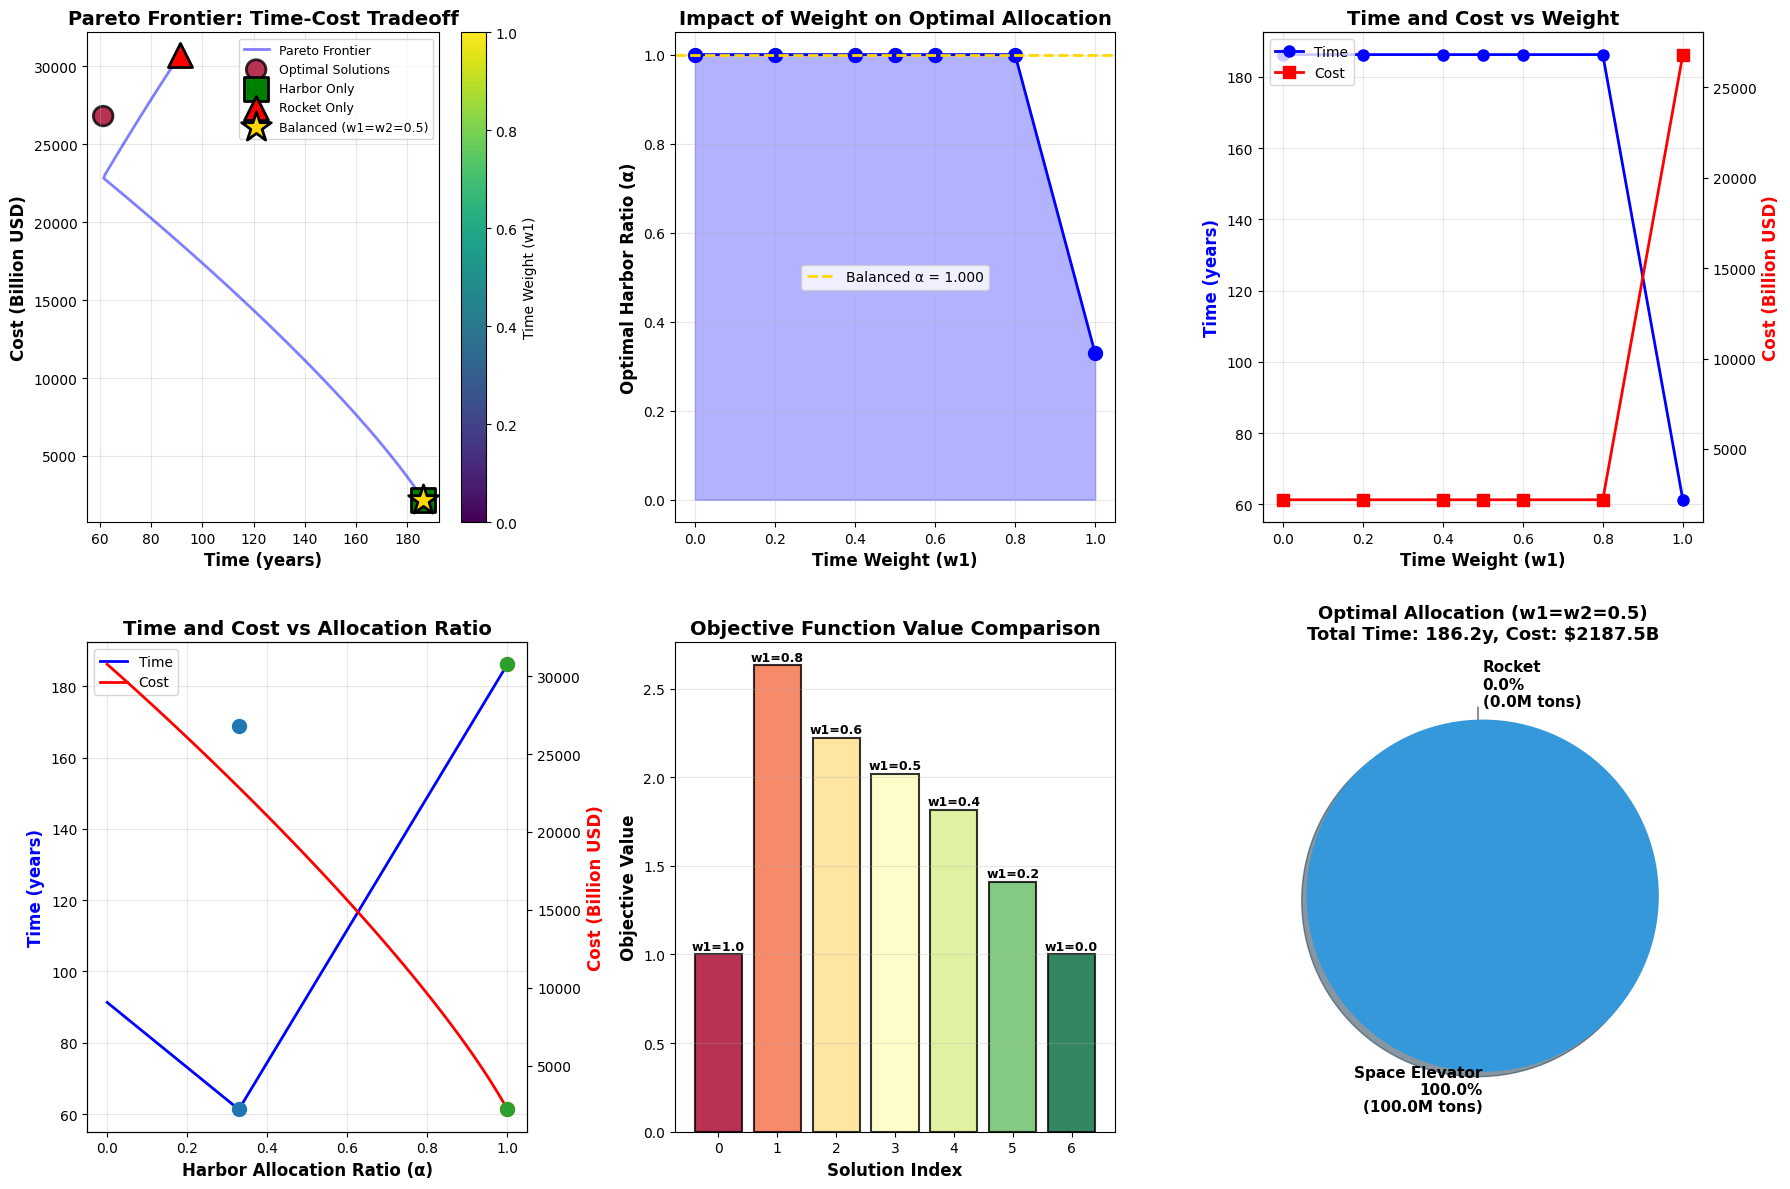


图表说明:
--------------------------------------------------------------------------------
1. Pareto Frontier: 展示时间-成本的权衡曲线和不同权重下的最优解
2. Weight Impact: 权重如何影响太空电梯的最优分配比例
3. Time & Cost vs Weight: 随着时间权重增加，时间缩短但成本上升
4. Time & Cost vs Allocation: 展示完整的帕累托前沿
5. Objective Values: 不同权重下的目标函数值对比
6. Optimal Allocation: 均衡权重下的运输分配饼图
--------------------------------------------------------------------------------


In [58]:
"""
可视化分析：帕累托前沿与权重影响
"""

fig = plt.figure(figsize=(18, 12))

# ==================== 子图1: 帕累托前沿（时间-成本空间） ====================
ax1 = plt.subplot(2, 3, 1)

# 绘制连续的帕累托前沿
alpha_range = np.linspace(0, 1, 101)
pareto_times = []
pareto_costs = []

for alpha in alpha_range:
    t, c = evaluate_hybrid_scheme(alpha)
    pareto_times.append(t)
    pareto_costs.append(c / 1e9)

ax1.plot(pareto_times, pareto_costs, 'b-', linewidth=2, alpha=0.5, label='Pareto Frontier')
ax1.scatter(df_solutions['time_years'], df_solutions['cost_billion'], 
           c=df_solutions['w1'], cmap='RdYlGn_r', s=200, edgecolors='black', linewidth=2,
           alpha=0.8, label='Optimal Solutions')

# 标注关键点
ax1.scatter([time_harbor_only], [cost_harbor_only/1e9], 
           marker='s', s=300, c='green', edgecolors='black', linewidth=2, 
           label='Harbor Only', zorder=5)
ax1.scatter([time_rocket_only], [cost_rocket_only/1e9], 
           marker='^', s=300, c='red', edgecolors='black', linewidth=2, 
           label='Rocket Only', zorder=5)
ax1.scatter([balanced_solution['time_years']], [balanced_solution['cost_billion']], 
           marker='*', s=500, c='gold', edgecolors='black', linewidth=2, 
           label='Balanced (w1=w2=0.5)', zorder=5)

ax1.set_xlabel('Time (years)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cost (Billion USD)', fontsize=12, fontweight='bold')
ax1.set_title('Pareto Frontier: Time-Cost Tradeoff', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9, loc='best')

# 添加colorbar
cbar1 = plt.colorbar(ax1.collections[1], ax=ax1)
cbar1.set_label('Time Weight (w1)', fontsize=10)

# ==================== 子图2: 权重 vs 最优α ====================
ax2 = plt.subplot(2, 3, 2)

ax2.plot(df_solutions['w1'], df_solutions['alpha'], 'bo-', linewidth=2, markersize=10)
ax2.axhline(y=alpha_balanced_opt, color='gold', linestyle='--', linewidth=2, 
            label=f'Balanced α = {alpha_balanced_opt:.3f}')
ax2.fill_between(df_solutions['w1'], 0, df_solutions['alpha'], alpha=0.3, color='blue')

ax2.set_xlabel('Time Weight (w1)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Optimal Harbor Ratio (α)', fontsize=12, fontweight='bold')
ax2.set_title('Impact of Weight on Optimal Allocation', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

# ==================== 子图3: 权重 vs 时间和成本 ====================
ax3 = plt.subplot(2, 3, 3)

ax3_twin = ax3.twinx()

line1 = ax3.plot(df_solutions['w1'], df_solutions['time_years'], 
                'b-o', linewidth=2, markersize=8, label='Time')
line2 = ax3_twin.plot(df_solutions['w1'], df_solutions['cost_billion'], 
                     'r-s', linewidth=2, markersize=8, label='Cost')

ax3.set_xlabel('Time Weight (w1)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Time (years)', fontsize=12, fontweight='bold', color='blue')
ax3_twin.set_ylabel('Cost (Billion USD)', fontsize=12, fontweight='bold', color='red')
ax3.set_title('Time and Cost vs Weight', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 合并图例
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax3.legend(lines, labels, fontsize=10, loc='upper left')

# ==================== 子图4: α vs 时间和成本 ====================
ax4 = plt.subplot(2, 3, 4)

ax4.plot(alpha_range, pareto_times, 'b-', linewidth=2, label='Time')
ax4_twin = ax4.twinx()
ax4_twin.plot(alpha_range, pareto_costs, 'r-', linewidth=2, label='Cost')

# 标注最优点
for _, sol in df_solutions.iterrows():
    if sol['w1'] in [0.0, 0.5, 1.0]:
        ax4.scatter([sol['alpha']], [sol['time_years']], s=100, zorder=5)
        ax4_twin.scatter([sol['alpha']], [sol['cost_billion']], s=100, zorder=5)

ax4.set_xlabel('Harbor Allocation Ratio (α)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Time (years)', fontsize=12, fontweight='bold', color='blue')
ax4_twin.set_ylabel('Cost (Billion USD)', fontsize=12, fontweight='bold', color='red')
ax4.set_title('Time and Cost vs Allocation Ratio', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

lines4 = ax4.get_lines() + ax4_twin.get_lines()
labels4 = [l.get_label() for l in lines4]
ax4.legend(lines4, labels4, fontsize=10, loc='upper left')

# ==================== 子图5: 目标函数值 ====================
ax5 = plt.subplot(2, 3, 5)

colors = plt.cm.RdYlGn_r(df_solutions['w1'])
bars = ax5.bar(range(len(df_solutions)), df_solutions['objective'], 
               color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# 标注w1值
for i, (idx, row) in enumerate(df_solutions.iterrows()):
    ax5.text(i, row['objective'] + 0.01, f"w1={row['w1']:.1f}", 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax5.set_xlabel('Solution Index', fontsize=12, fontweight='bold')
ax5.set_ylabel('Objective Value', fontsize=12, fontweight='bold')
ax5.set_title('Objective Function Value Comparison', fontsize=14, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')

# ==================== 子图6: 运输比例饼图（均衡方案） ====================
ax6 = plt.subplot(2, 3, 6)

sizes = [alpha_balanced_opt * 100, (1 - alpha_balanced_opt) * 100]
labels_pie = [f'Space Elevator\n{alpha_balanced_opt*100:.1f}%\n({harbor_payload_kg/1e9:.1f}M tons)',
              f'Rocket\n{(1-alpha_balanced_opt)*100:.1f}%\n({rocket_payload_kg/1e9:.1f}M tons)']
colors_pie = ['#3498db', '#e74c3c']
explode = (0.05, 0.05)

ax6.pie(sizes, explode=explode, labels=labels_pie, colors=colors_pie, autopct='',
        shadow=True, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax6.set_title(f'Optimal Allocation (w1=w2=0.5)\nTotal Time: {balanced_solution["time_years"]:.1f}y, Cost: ${balanced_solution["cost_billion"]:.1f}B', 
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n图表说明:")
print("-" * 80)
print("1. Pareto Frontier: 展示时间-成本的权衡曲线和不同权重下的最优解")
print("2. Weight Impact: 权重如何影响太空电梯的最优分配比例")
print("3. Time & Cost vs Weight: 随着时间权重增加，时间缩短但成本上升")
print("4. Time & Cost vs Allocation: 展示完整的帕累托前沿")
print("5. Objective Values: 不同权重下的目标函数值对比")
print("6. Optimal Allocation: 均衡权重下的运输分配饼图")
print("-" * 80)

In [59]:
"""
敏感性分析：学习率参数对最优解的影响
"""

print("\n" + "=" * 80)
print("敏感性分析：学习率参数的影响".center(80))
print("=" * 80)

# 不同的学习率组合
b_rocket_values = [0.10, 0.15, 0.20, 0.25, 0.30]
b_harbor_values = [0.05, 0.10, 0.15, 0.20]

# 固定权重为均衡 (w1=w2=0.5)
w1_fixed, w2_fixed = 0.5, 0.5

sensitivity_results = []

print("\n【火箭学习率敏感性分析】(太空电梯 b=0.15 固定)")
print("-" * 80)
print(f"{'火箭学习率':<15} {'最优α':<12} {'时间(年)':<15} {'成本(亿$)':<15} {'火箭平均成本($/kg)':<20}")
print("-" * 80)

for b_r in b_rocket_values:
    # 临时修改全局参数
    def calc_with_b_rocket(alpha):
        harbor_payload = total_materials_kg * alpha
        rocket_payload = total_materials_kg * (1 - alpha)
        
        h_cost, h_avg, h_time = calculate_cost_with_learning_annual(
            harbor_payload, harbor_annual_capacity, C1_harbor, 0.15
        ) if alpha > 0 else (0, 0, 0)
        
        r_cost, r_avg, r_time = calculate_cost_with_learning_annual(
            rocket_payload, rocket_annual_capacity, C1_rocket, b_r
        ) if alpha < 1 else (0, 0, 0)
        
        time_total = max(h_time, r_time)
        cost_total = h_cost + r_cost
        
        # 计算目标函数
        T_min_temp = min(h_time if alpha == 1 else float('inf'), 
                        r_time if alpha == 0 else float('inf'),
                        time_total)
        C_min_temp = min(h_cost if alpha == 1 else float('inf'), 
                        r_cost if alpha == 0 else float('inf'))
        
        obj = w1_fixed * (time_total / T_min_temp) + w2_fixed * (cost_total / C_min_temp)
        return obj, time_total, cost_total, r_avg
    
    # 网格搜索找最优α
    best_alpha = 0
    best_obj = float('inf')
    best_time = 0
    best_cost = 0
    best_rocket_avg = 0
    
    for alpha in np.linspace(0, 1, 51):
        obj, t, c, r_avg = calc_with_b_rocket(alpha)
        if obj < best_obj:
            best_obj = obj
            best_alpha = alpha
            best_time = t
            best_cost = c
            best_rocket_avg = r_avg
    
    print(f"b_rocket={b_r:<7} {best_alpha:<12.4f} {best_time:<15.2f} {best_cost/1e9:<15.2f} ${best_rocket_avg:<19.2f}")
    
    sensitivity_results.append({
        'param': f'b_rocket={b_r}',
        'b_value': b_r,
        'alpha': best_alpha,
        'time': best_time,
        'cost': best_cost/1e9
    })

print("\n【太空电梯学习率敏感性分析】(火箭 b=0.20 固定)")
print("-" * 80)
print(f"{'电梯学习率':<15} {'最优α':<12} {'时间(年)':<15} {'成本(亿$)':<15} {'电梯平均成本($/kg)':<20}")
print("-" * 80)

for b_h in b_harbor_values:
    # 类似的分析
    def calc_with_b_harbor(alpha):
        harbor_payload = total_materials_kg * alpha
        rocket_payload = total_materials_kg * (1 - alpha)
        
        h_cost, h_avg, h_time = calculate_cost_with_learning_annual(
            harbor_payload, harbor_annual_capacity, C1_harbor, b_h
        ) if alpha > 0 else (0, 0, 0)
        
        r_cost, r_avg, r_time = calculate_cost_with_learning_annual(
            rocket_payload, rocket_annual_capacity, C1_rocket, 0.20
        ) if alpha < 1 else (0, 0, 0)
        
        time_total = max(h_time, r_time)
        cost_total = h_cost + r_cost
        
        T_min_temp = min(h_time if alpha == 1 else float('inf'), 
                        r_time if alpha == 0 else float('inf'),
                        time_total)
        C_min_temp = min(h_cost if alpha == 1 else float('inf'), 
                        r_cost if alpha == 0 else float('inf'))
        
        obj = w1_fixed * (time_total / T_min_temp) + w2_fixed * (cost_total / C_min_temp)
        return obj, time_total, cost_total, h_avg
    
    best_alpha = 0
    best_obj = float('inf')
    best_time = 0
    best_cost = 0
    best_harbor_avg = 0
    
    for alpha in np.linspace(0, 1, 51):
        obj, t, c, h_avg = calc_with_b_harbor(alpha)
        if obj < best_obj:
            best_obj = obj
            best_alpha = alpha
            best_time = t
            best_cost = c
            best_harbor_avg = h_avg
    
    print(f"b_harbor={b_h:<7} {best_alpha:<12.4f} {best_time:<15.2f} {best_cost/1e9:<15.2f} ${best_harbor_avg:<19.2f}")
print("=" * 80)


                                 敏感性分析：学习率参数的影响                                 

【火箭学习率敏感性分析】(太空电梯 b=0.15 固定)
--------------------------------------------------------------------------------
火箭学习率           最优α          时间(年)           成本(亿$)          火箭平均成本($/kg)        
--------------------------------------------------------------------------------
b_rocket=0.1     0.0200       89.50           42022.12        $428.20             
b_rocket=0.15    0.0200       89.50           38943.00        $396.78             
b_rocket=0.2     0.0200       89.50           36121.85        $368.00             
b_rocket=0.25    0.0200       89.50           33535.68        $341.61             
b_rocket=0.3     0.0200       89.50           31163.64        $317.40             

【太空电梯学习率敏感性分析】(火箭 b=0.20 固定)
--------------------------------------------------------------------------------
电梯学习率           最优α          时间(年)           成本(亿$)          电梯平均成本($/kg)        
------------------------------------